# Random Matrix Theory Analysis of Latin American Inequality Co-movements
## SEDLAC Data · 15 Countries · 2001–2023

**Paper target:** *Economics Letters*  
**Data source:** SEDLAC (CEDLAS and The World Bank), September 2025  
**Method:** Marchenko–Pastur spectral analysis of the Gini correlation matrix

---

## 0. Dependencies

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import gaussian_kde
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic constants ────────────────────────────────────────────────────────
DARK   = '#0a0e17'
PANEL  = '#111827'
PANEL2 = '#1a2235'
GRID   = '#1e2d40'
BORDER = '#2a3a50'
WHITE  = '#e8edf5'
MUTED  = '#7a8fa8'
GOLD   = '#e8b84b'
TEAL   = '#2ec4b6'
CORAL  = '#e84855'
BLUE   = '#3a86ff'
VIOLET = '#9b5de5'
MINT   = '#06d6a0'

# ── Aesthetic constants ────────────────────────────────────────────────────────
BG      = '#ffffff'
PANEL   = '#ffffff'
GRID    = '#e8e8e8'
BORDER  = '#cccccc'
BLACK   = '#1a1a1a'
MUTED   = '#666666'
BLUE    = '#2166ac'
RED     = '#d6604d'
TEAL    = '#35978f'
GOLD    = '#bf812d'
VIOLET  = '#762a83'
GREEN   = '#1b7837'

COUNTRY_COLORS = [
    '#2166ac','#d6604d','#35978f','#bf812d','#762a83',
    '#1b7837','#e08214','#4393c3','#f4a582','#80cdc1',
    '#c2a5cf','#a6dba0','#8073ac','#d9ef8b','#998ec3'
]

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    BORDER,
    'axes.labelcolor':   BLACK,
    'axes.titlecolor':   BLACK,
    'axes.grid':         True,
    'axes.axisbelow':    True,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'grid.alpha':        1.0,
    'grid.linestyle':    '--',
    'xtick.color':       BLACK,
    'ytick.color':       BLACK,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'text.color':        BLACK,
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.framealpha': 1.0,
    'legend.facecolor':  BG,
    'legend.edgecolor':  BORDER,
    'legend.fontsize':   8.5,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': BG,
    'savefig.format':    'pdf',
})

COUNTRY_LABELS = {
    'Argentina':'ARG','Bolivia':'BOL','Brazil':'BRA','Chile':'CHL',
    'Colombia':'COL','Costa Rica':'CRI','Dominican':'DOM','Ecuador':'ECU',
    'El Salvador':'SLV','Honduras':'HND','Mexico':'MEX','Panama':'PAN',
    'Paraguay':'PRY','Peru':'PER','Uruguay':'URY'
}
COUNTRY_COLORS = [
    '#e84855','#3a86ff','#e8b84b','#2ec4b6','#9b5de5',
    '#06d6a0','#ff6b6b','#48cae4','#f77f00','#4cc9f0',
    '#7209b7','#b5e48c','#f72585','#90e0ef','#c77dff'
]

print('Dependencies loaded.')

## 1. Data Loading & Preprocessing

In [5]:
# ── Parse SEDLAC Excel ─────────────────────────────────────────────────────────
df_raw = pd.read_excel('2025_Act1_inequality_LAC.xlsx',
                       sheet_name='indices pci', header=None)

rows = []
current_country = None
COUNTRIES_15 = list(COUNTRY_LABELS.keys())

for idx, row in df_raw.iterrows():
    val0 = str(row[0]).strip() if pd.notna(row[0]) else ''
    val1 = row[1]
    for c in COUNTRIES_15:
        if val0.startswith(c):
            current_country = c
            break
    try:
        year = int(float(val0))
        if 1960 <= year <= 2030 and current_country and pd.notna(val1):
            rows.append({'country': current_country, 'year': year, 'gini': float(val1)})
    except:
        pass

df_all = pd.DataFrame(rows).drop_duplicates(['country','year'])

# ── Window: 2001–2023, 15 countries ───────────────────────────────────────────
df = df_all[(df_all['year'] >= 2001) & (df_all['year'] <= 2023)]
pivot_raw = df.pivot(index='year', columns='country', values='gini').sort_index()
pivot = pivot_raw.interpolate(method='linear', axis=0).ffill().bfill()

# ── Annual increments, z-scored ───────────────────────────────────────────────
returns = pivot.diff().dropna()
Z = (returns - returns.mean()) / returns.std()

N = Z.shape[1]   # 15 countries
T = Z.shape[0]   # 22 annual increments
Q = T / N        # 1.467

print(f'Panel: N={N} countries, T={T} increments, Q=T/N={Q:.4f}')
print(f'Countries: {", ".join(list(Z.columns))}')
print(f'\nGini descriptive stats (2001-2023):')
print(pivot.describe().round(4))

# Save CSV
pivot.to_csv('gini_panel_2001_2023.csv')
df_all.to_csv('gini_all_years.csv', index=False)
print('\nCSV files saved: gini_panel_2001_2023.csv, gini_all_years.csv')

Panel: N=15 countries, T=22 increments, Q=T/N=1.4667
Countries: Argentina, Bolivia, Brazil, Chile, Colombia, Costa Rica, Dominican, Ecuador, El Salvador, Honduras, Mexico, Panama, Paraguay, Peru, Uruguay

Gini descriptive stats (2001-2023):
country  Argentina  Bolivia   Brazil    Chile  Colombia  Costa Rica  \
count      23.0000  23.0000  23.0000  23.0000   23.0000     23.0000   
mean        0.5279   0.4905   0.5380   0.4700    0.5316      0.4867   
std         0.0016   0.0643   0.0233   0.0228    0.0187      0.0105   
min         0.5221   0.4091   0.4884   0.4296    0.4956      0.4671   
25%         0.5279   0.4412   0.5255   0.4552    0.5179      0.4822   
50%         0.5279   0.4759   0.5337   0.4682    0.5348      0.4857   
75%         0.5279   0.5555   0.5520   0.4760    0.5455      0.4914   
max         0.5327   0.5928   0.5832   0.5115    0.5620      0.5159   

country  Dominican  Ecuador  El Salvador  Honduras   Mexico   Panama  \
count      23.0000  23.0000      23.0000   23.0

## 2. Figure 1 — Gini Time Series Panel

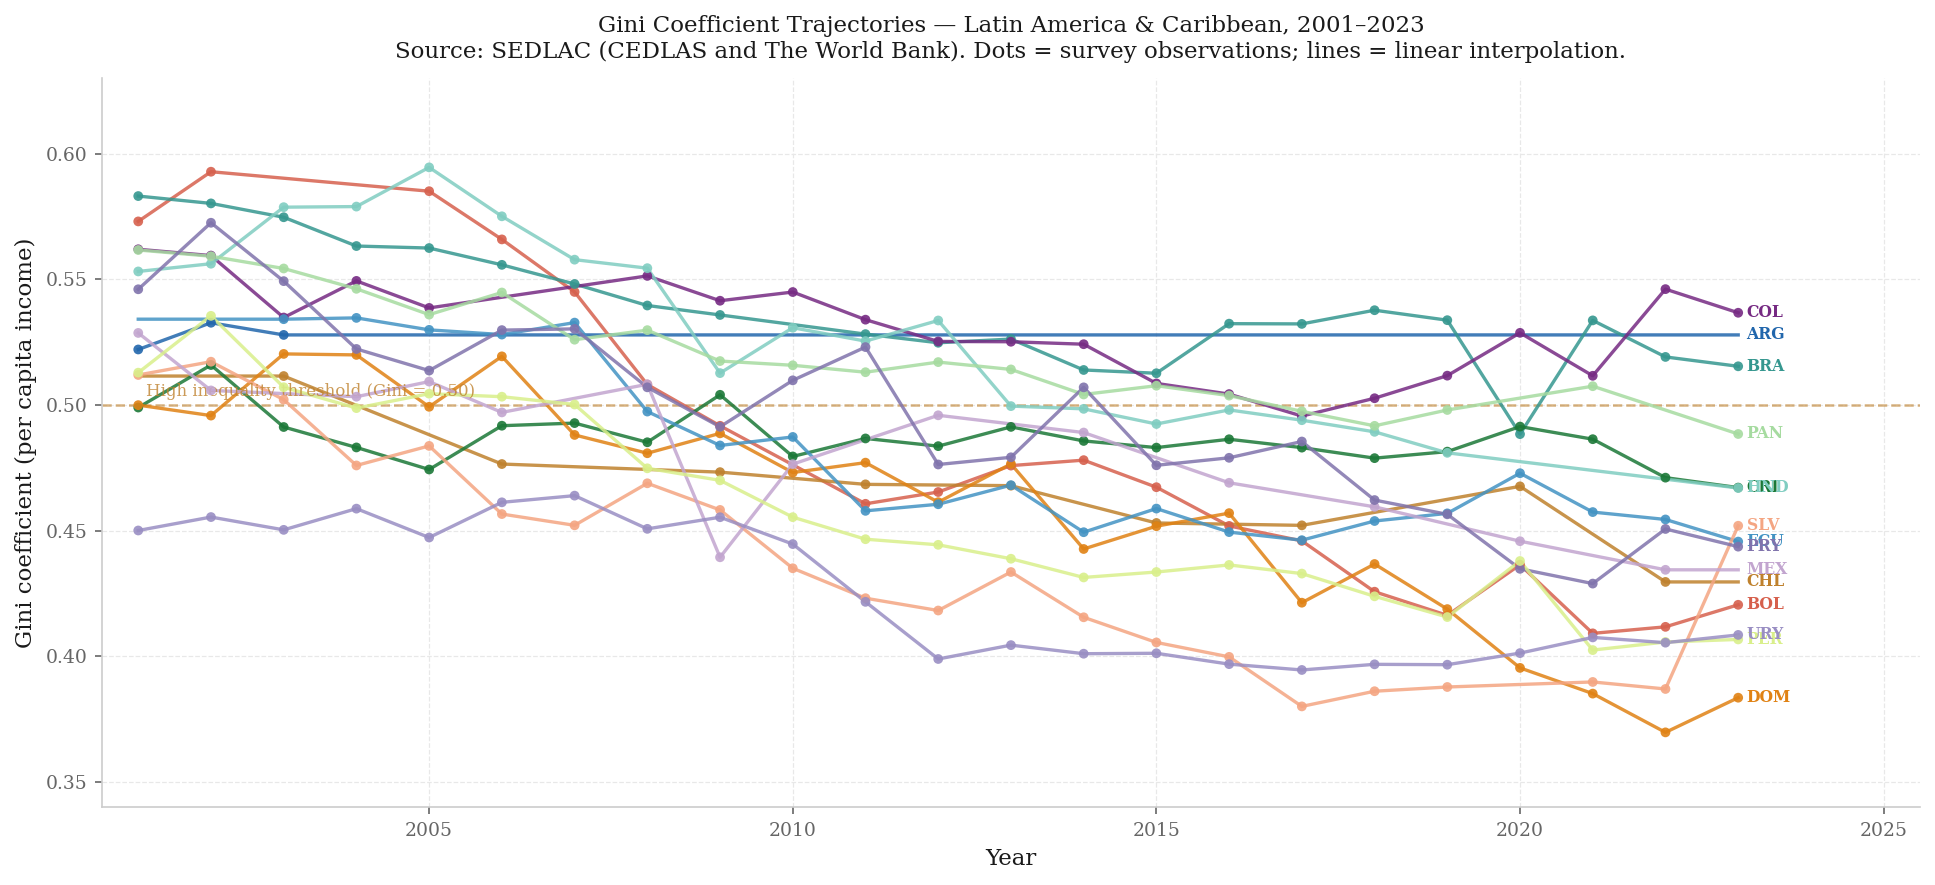

Figure 1 saved.


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

countries = list(pivot.columns)
short = [COUNTRY_LABELS[c] for c in countries]

for i, (country, color) in enumerate(zip(countries, COUNTRY_COLORS)):
    series = pivot[country]
    raw    = pivot_raw[country].dropna()
    ax.plot(series.index, series.values, color=color, lw=1.6, alpha=0.85, zorder=3)
    ax.scatter(raw.index, raw.values, color=color, s=22, zorder=4,
               edgecolors='none', alpha=0.9)
    # Label at last point
    last_y = series.iloc[-1]
    ax.annotate(COUNTRY_LABELS[country],
                xy=(series.index[-1], last_y),
                xytext=(4, 0), textcoords='offset points',
                color=color, fontsize=7.5, va='center', fontweight='bold')

# Reference lines
ax.axhline(0.50, color=GOLD, lw=1.2, ls='--', alpha=0.6, zorder=2)
ax.text(2001.1, 0.502, 'High inequality threshold (Gini = 0.50)',
        color=GOLD, fontsize=8, alpha=0.8, va='bottom')

ax.set_xlim(2000.5, 2025.5)
ax.set_ylim(0.34, 0.63)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Gini coefficient (per capita income)', fontsize=11)
ax.set_title(
    'Gini Coefficient Trajectories — Latin America & Caribbean, 2001–2023\n'
    'Source: SEDLAC (CEDLAS and The World Bank). Dots = survey observations; lines = linear interpolation.',
    fontsize=11, pad=10
)
ax.tick_params(colors=MUTED)

plt.tight_layout()
plt.savefig('fig1_gini_series.pdf', facecolor='white')
plt.savefig('fig1_gini_series.png', facecolor='white', dpi=300)
plt.show()
print('Figure 1 saved.')

## 3. RMT Core: Correlation Matrix & Marchenko–Pastur

In [19]:
# ── Empirical correlation matrix ───────────────────────────────────────────────
C = Z.corr()
C_vals = C.values

# ── Eigendecomposition ────────────────────────────────────────────────────────
eigenvalues, eigenvectors = np.linalg.eigh(C_vals)
idx_sorted  = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx_sorted]
eigenvectors = eigenvectors[:, idx_sorted]

# ── Marchenko–Pastur bounds ───────────────────────────────────────────────────
sigma2       = 1.0
lambda_plus  = sigma2 * (1 + 1/Q + 2*np.sqrt(1/Q))
lambda_minus = sigma2 * (1 + 1/Q - 2*np.sqrt(1/Q))

# ── MP density ────────────────────────────────────────────────────────────────
def mp_density(x, Q, sigma2=1.0):
    lp = sigma2 * (1 + 1/Q + 2*np.sqrt(1/Q))
    lm = sigma2 * (1 + 1/Q - 2*np.sqrt(1/Q))
    out = np.where(
        (x >= lm) & (x <= lp),
        Q / (2 * np.pi * sigma2) * np.sqrt(np.maximum((lp-x)*(x-lm), 0)) / x,
        0.0
    )
    return out

mp_x = np.linspace(1e-4, max(eigenvalues)*1.15, 2000)
mp_y = mp_density(mp_x, Q)

# ── Outlier detection ─────────────────────────────────────────────────────────
outliers = eigenvalues[eigenvalues > lambda_plus]
bulk     = eigenvalues[eigenvalues <= lambda_plus]

# ── Participation ratio ───────────────────────────────────────────────────────
def participation_ratio(v):
    return 1.0 / np.sum(v**4)

print('=== RMT Summary ===')
print(f'N={N}, T={T}, Q={Q:.4f}')
print(f'Marchenko-Pastur: λ- = {lambda_minus:.4f}, λ+ = {lambda_plus:.4f}')
print(f'Outlier eigenvalues: {np.round(outliers, 4)}')
print(f'Variance explained by outliers: {outliers.sum()/N*100:.2f}%')
print(f'Trace check: {eigenvalues.sum():.4f} (should = {N})')
print(f'\nTop 5 eigenvalues and PR:')
for i in range(5):
    pr = participation_ratio(eigenvectors[:, i])
    status = '*** OUTLIER ***' if eigenvalues[i] > lambda_plus else 'bulk'
    print(f'  λ{i+1} = {eigenvalues[i]:.4f}  PR={pr:.2f}/{N}  [{status}]')

# Save correlation matrix CSV
C.to_csv('correlation_matrix.csv')
print('\nCorrelation matrix saved: correlation_matrix.csv')

=== RMT Summary ===
N=15, T=22, Q=1.4667
Marchenko-Pastur: λ- = 0.0304, λ+ = 3.3333
Outlier eigenvalues: [3.4798]
Variance explained by outliers: 23.20%
Trace check: 15.0000 (should = 15)

Top 5 eigenvalues and PR:
  λ1 = 3.4798  PR=8.84/15  [*** OUTLIER ***]
  λ2 = 2.5113  PR=8.77/15  [bulk]
  λ3 = 1.8215  PR=5.37/15  [bulk]
  λ4 = 1.4446  PR=7.60/15  [bulk]
  λ5 = 1.1786  PR=4.32/15  [bulk]

Correlation matrix saved: correlation_matrix.csv


## 4. Figure 2 — Eigenvalue Spectrum vs. Marchenko–Pastur

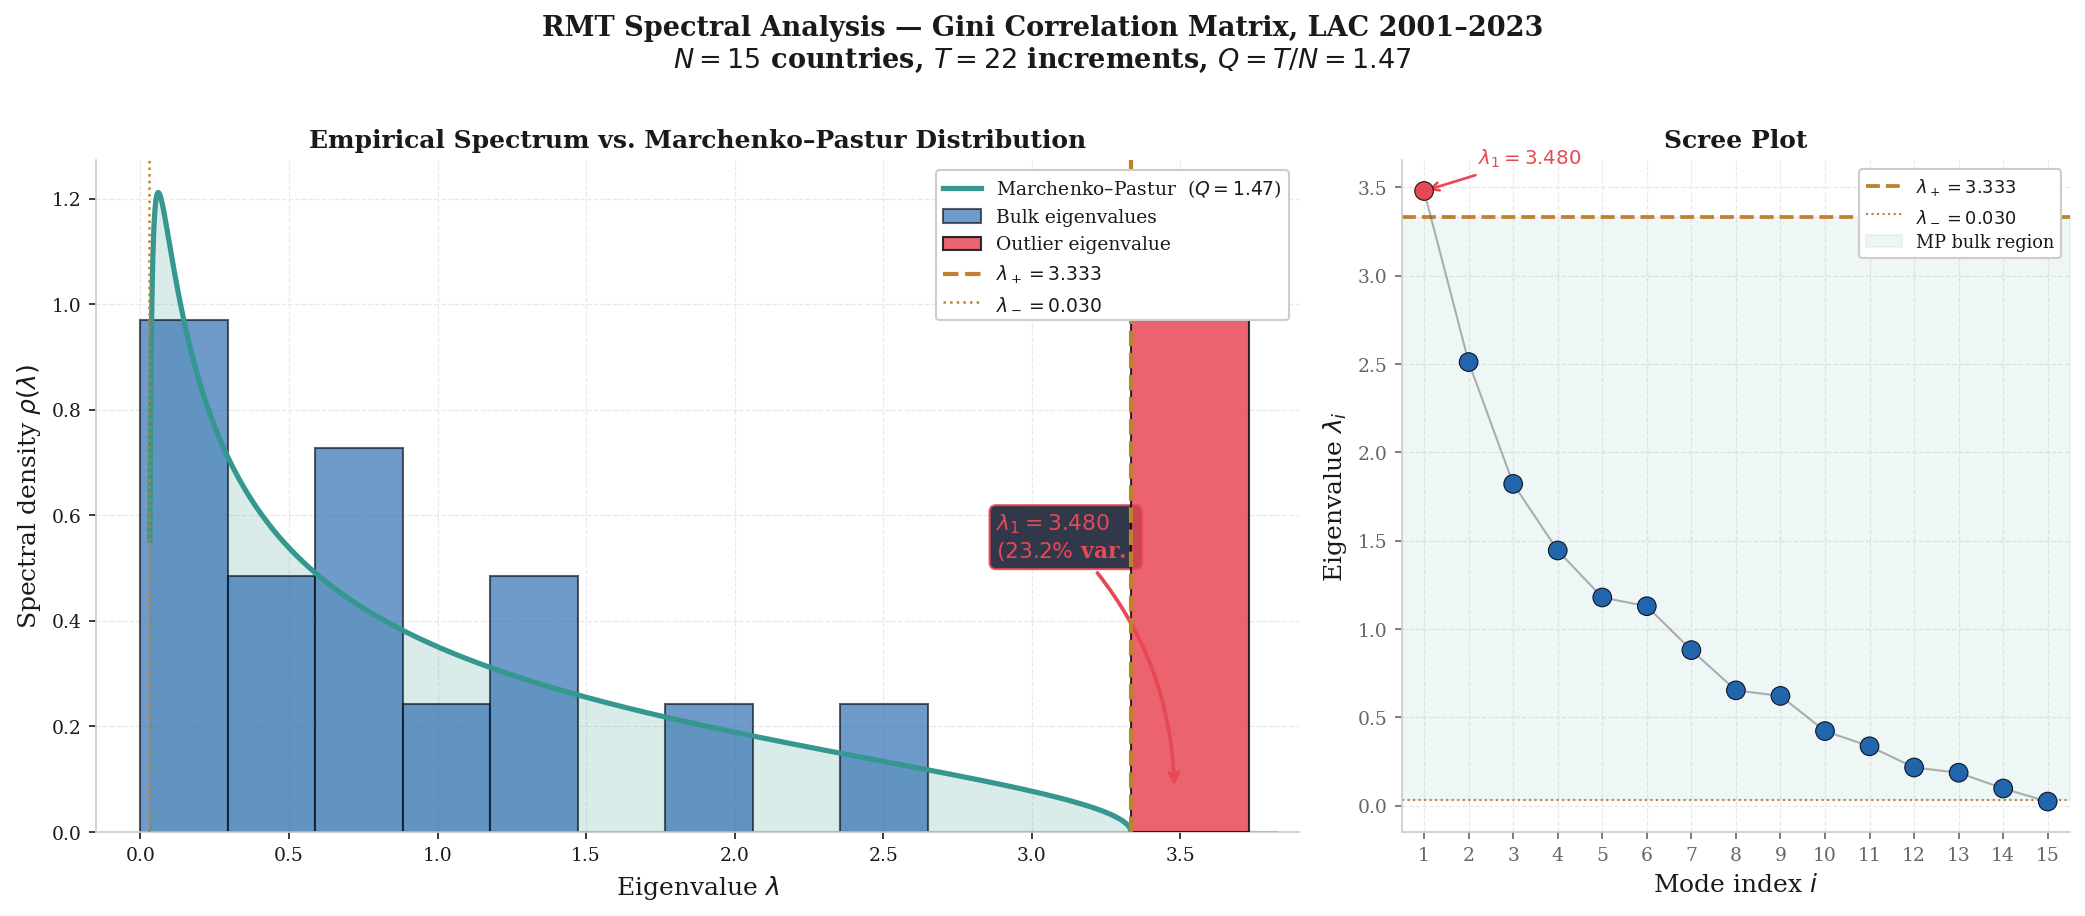

Figure 2 saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          gridspec_kw={'width_ratios': [1.8, 1]})

# ── LEFT: Histogram + MP density ──────────────────────────────────────────────
ax = axes[0]

# MP filled region
mp_mask = (mp_x >= lambda_minus) & (mp_x <= lambda_plus)
ax.fill_between(mp_x[mp_mask], mp_y[mp_mask],
                alpha=0.18, color=TEAL, zorder=1)
ax.plot(mp_x[mp_mask], mp_y[mp_mask],
        color=TEAL, lw=2.5, zorder=3,
        label=f'Marchenko–Pastur  ($Q={Q:.2f}$)')

# Empirical eigenvalue histogram
bins = np.linspace(0, eigenvalues.max()*1.1, 14)
ax.hist(bulk, bins=bins, density=True,
        color=BLUE, alpha=0.65, edgecolor=DARK, lw=0.8,
        label='Bulk eigenvalues', zorder=2)
ax.hist(outliers, bins=[lambda_plus, outliers[0]+0.25], density=False,
        color=CORAL, alpha=0.85, edgecolor=DARK, lw=0.8,
        label='Outlier eigenvalue', zorder=4)

# MP bounds
ax.axvline(lambda_plus,  color=GOLD, lw=2, ls='--', zorder=5,
           label=f'$\\lambda_+ = {lambda_plus:.3f}$')
ax.axvline(lambda_minus, color=GOLD, lw=1.2, ls=':', zorder=5,
           label=f'$\\lambda_- = {lambda_minus:.3f}$')

# Outlier annotation with bracket
for lam in outliers:
    ax.annotate(
        f'$\\lambda_1 = {lam:.3f}$\n$({lam/N*100:.1f}\\%$ var.$)$',
        xy=(lam, 0.08), xytext=(lam - 0.6, 0.52),
        fontsize=10.5, color=CORAL, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.8,
                        connectionstyle='arc3,rad=-0.2'),
        bbox=dict(boxstyle='round,pad=0.3', facecolor=PANEL2,
                  edgecolor=CORAL, alpha=0.9)
    )

ax.set_xlabel('Eigenvalue $\\lambda$', fontsize=12)
ax.set_ylabel('Spectral density $\\rho(\\lambda)$', fontsize=12)
ax.set_title('Empirical Spectrum vs. Marchenko–Pastur Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-0.15, eigenvalues.max()*1.12)
ax.set_ylim(bottom=0)

# ── RIGHT: Eigenvalue index plot (scree) ──────────────────────────────────────
ax2 = axes[1]

colors_scree = [CORAL if l > lambda_plus else BLUE for l in eigenvalues]
ax2.scatter(range(1, N+1), eigenvalues, c=colors_scree, s=80,
            zorder=4, edgecolors=DARK, lw=0.5)
ax2.plot(range(1, N+1), eigenvalues, color=MUTED, lw=1, ls='-',
         alpha=0.5, zorder=3)
ax2.axhline(lambda_plus,  color=GOLD, lw=1.8, ls='--', zorder=2,
            label=f'$\\lambda_+ = {lambda_plus:.3f}$')
ax2.axhline(lambda_minus, color=GOLD, lw=1.0, ls=':',  zorder=2,
            label=f'$\\lambda_- = {lambda_minus:.3f}$')

# Annotate λ1
ax2.annotate(f'$\\lambda_1={eigenvalues[0]:.3f}$',
             xy=(1, eigenvalues[0]), xytext=(2.2, eigenvalues[0]+0.15),
             color=CORAL, fontsize=9.5, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.3))

ax2.fill_between([0.5, N+0.5], lambda_minus, lambda_plus,
                 alpha=0.08, color=TEAL, zorder=1,
                 label='MP bulk region')

ax2.set_xlabel('Mode index $i$', fontsize=12)
ax2.set_ylabel('Eigenvalue $\\lambda_i$', fontsize=12)
ax2.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8.5, loc='upper right')
ax2.set_xlim(0.5, N+0.5)
ax2.set_xticks(range(1, N+1))
ax2.tick_params(colors=MUTED)

fig.suptitle(
    'RMT Spectral Analysis — Gini Correlation Matrix, LAC 2001–2023\n'
    f'$N={N}$ countries, $T={T}$ increments, $Q=T/N={Q:.2f}$',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('fig2_spectrum.pdf', dpi=300)
plt.savefig('fig2_spectrum.png', dpi=300)
plt.show()
print('Figure 2 saved.')


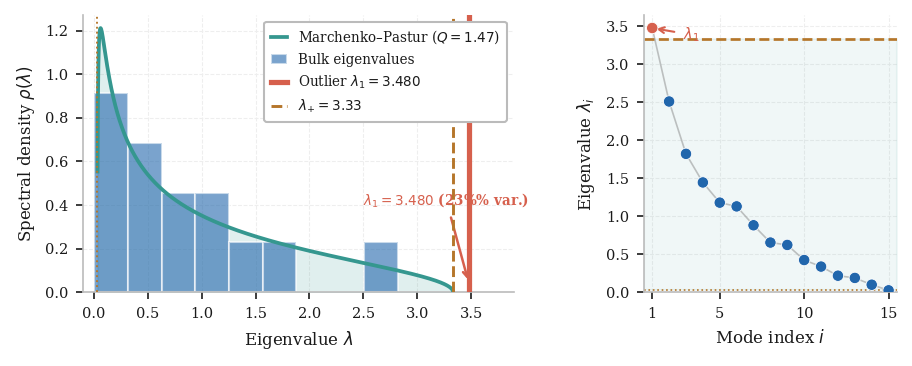

Figure 1 saved.


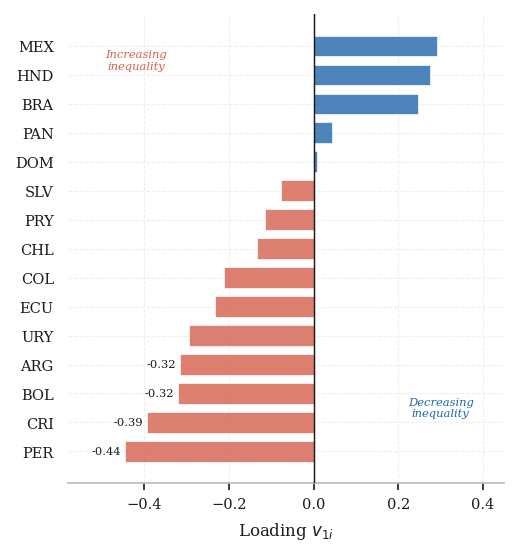

Figure 2 saved.


In [21]:
# ── FIGURE 1: Spectrum + Scree ─────────────────────────────────────────────────
BG    = '#ffffff'; PANEL = '#ffffff'; GRID  = '#eeeeee'; BORDER = '#bbbbbb'
BLACK = '#1a1a1a'; MUTED = '#888888'; BLUE  = '#2166ac'; CORAL  = '#d6604d'
TEAL  = '#35978f'; GOLD  = '#b5762a'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': BORDER, 'axes.labelcolor': BLACK,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.5,
    'grid.linestyle': '--', 'grid.alpha': 1.0,
    'xtick.color': BLACK, 'ytick.color': BLACK,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'text.color': BLACK, 'font.family': 'serif',
    'font.size': 8, 'axes.titlesize': 8, 'axes.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': True, 'legend.framealpha': 1.0,
    'legend.facecolor': BG, 'legend.edgecolor': BORDER,
    'legend.fontsize': 6.5,
})

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.4),
                          gridspec_kw={'width_ratios': [1.7, 1],
                                       'wspace': 0.38})

# ── LEFT: Histogram + MP density ─────────────────────────────────────────────
ax = axes[0]

mp_mask = (mp_x >= lambda_minus) & (mp_x <= lambda_plus)
ax.fill_between(mp_x[mp_mask], mp_y[mp_mask],
                alpha=0.15, color=TEAL, zorder=1)
ax.plot(mp_x[mp_mask], mp_y[mp_mask],
        color=TEAL, lw=1.8, zorder=3,
        label=f'Marchenko–Pastur ($Q={Q:.2f}$)')

bins = np.linspace(0, eigenvalues.max()*1.08, 13)
ax.hist(bulk, bins=bins, density=True,
        color=BLUE, alpha=0.60, edgecolor='white', lw=0.5,
        label='Bulk eigenvalues', zorder=2)

ax.axvline(outliers[0], color=CORAL, lw=2.5, zorder=5,
           label=f'Outlier $\\lambda_1={outliers[0]:.3f}$')
ax.axvline(lambda_plus, color=GOLD, lw=1.4, ls='--', zorder=4,
           label=f'$\\lambda_{{+}}={lambda_plus:.2f}$')
ax.axvline(lambda_minus, color=GOLD, lw=0.9, ls=':', zorder=4)

# Annotation — %% para evitar latex literal, flecha apunta a la línea roja
ax.annotate(
    f'$\\lambda_1={outliers[0]:.3f}$ ({outliers[0]/N*100:.0f}%% var.)',
    xy=(outliers[0], 0.04),
    xytext=(2.50, 0.40),
    fontsize=6.5, color=CORAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.2,
                    connectionstyle='arc3,rad=0.0'))

ax.set_xlabel('Eigenvalue $\\lambda$')
ax.set_ylabel('Spectral density $\\rho(\\lambda)$')
ax.legend(loc='upper right', handlelength=1.2, borderpad=0.5)
ax.set_xlim(-0.1, eigenvalues.max()*1.12)
ax.set_ylim(bottom=0)

# ── RIGHT: Scree plot ─────────────────────────────────────────────────────────
ax2 = axes[1]

colors_sc = [CORAL if l > lambda_plus else BLUE for l in eigenvalues]
ax2.scatter(range(1, N+1), eigenvalues,
            c=colors_sc, s=30, zorder=4,
            edgecolors='white', lw=0.4)
ax2.plot(range(1, N+1), eigenvalues,
         color=MUTED, lw=0.8, ls='-', alpha=0.5, zorder=3)
ax2.axhline(lambda_plus,  color=GOLD, lw=1.3, ls='--', zorder=2)
ax2.axhline(lambda_minus, color=GOLD, lw=0.8, ls=':', zorder=2)
ax2.fill_between([0.5, N+0.5], lambda_minus, lambda_plus,
                 alpha=0.07, color=TEAL, zorder=1)

ax2.annotate('$\\lambda_1$',
             xy=(1, eigenvalues[0]),
             xytext=(2.8, eigenvalues[0] - 0.15),
             fontsize=7, color=CORAL, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.0))

ax2.set_xlabel('Mode index $i$')
ax2.set_ylabel('Eigenvalue $\\lambda_i$')
ax2.set_xlim(0.5, N + 0.5)
ax2.set_xticks([1, 5, 10, 15])
ax2.set_ylim(bottom=0)

plt.savefig('fig1_spectrum.pdf', dpi=300, bbox_inches='tight', facecolor=BG)
plt.savefig('fig1_spectrum.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 1 saved.')


# ── FIGURE 2: Eigenvector loadings mode 1 ────────────────────────────────────
fig, ax = plt.subplots(figsize=(3.35, 3.6))

v1    = eigenvectors[:, 0]
idx_s = np.argsort(v1)
v_s   = v1[idx_s]
c_s   = [short[i] for i in idx_s]
col_s = [CORAL if x < 0 else BLUE for x in v_s]

bars = ax.barh(range(N), v_s,
               color=col_s, alpha=0.80,
               edgecolor='white', linewidth=0.4,
               height=0.72)

# Labels solo para los 4 más extremos
for i, (bar, val) in enumerate(zip(bars, v_s)):
    if abs(val) >= sorted(abs(v_s))[-4]:
        xpos = val + (0.010 if val >= 0 else -0.010)
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha=ha,
                fontsize=5.5, color=BLACK)

ax.axvline(0, color=BLACK, lw=0.7, zorder=5)
ax.set_yticks(range(N))
ax.set_yticklabels(c_s, fontsize=7)
ax.set_xlabel('Loading $v_{1i}$')
ax.set_xlim(-0.58, 0.45)
ax.tick_params(left=False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Azul (positivo) = co-mueve con factor regional = decreasing inequality
# Coral (negativo) = contra el factor = increasing inequality
ax.text( 0.30,  1.2, 'Decreasing\ninequality',
         fontsize=5.5, color=BLUE,  ha='center', style='italic')
ax.text(-0.42, 13.2, 'Increasing\ninequality',
         fontsize=5.5, color=CORAL, ha='center', style='italic')

plt.tight_layout(pad=0.4)
plt.savefig('fig2_loadings.pdf', dpi=300, bbox_inches='tight', facecolor=BG)
plt.savefig('fig2_loadings.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 2 saved.')

## 5. Figure 3 — Correlation Matrix Heatmap (Hierarchically Ordered)

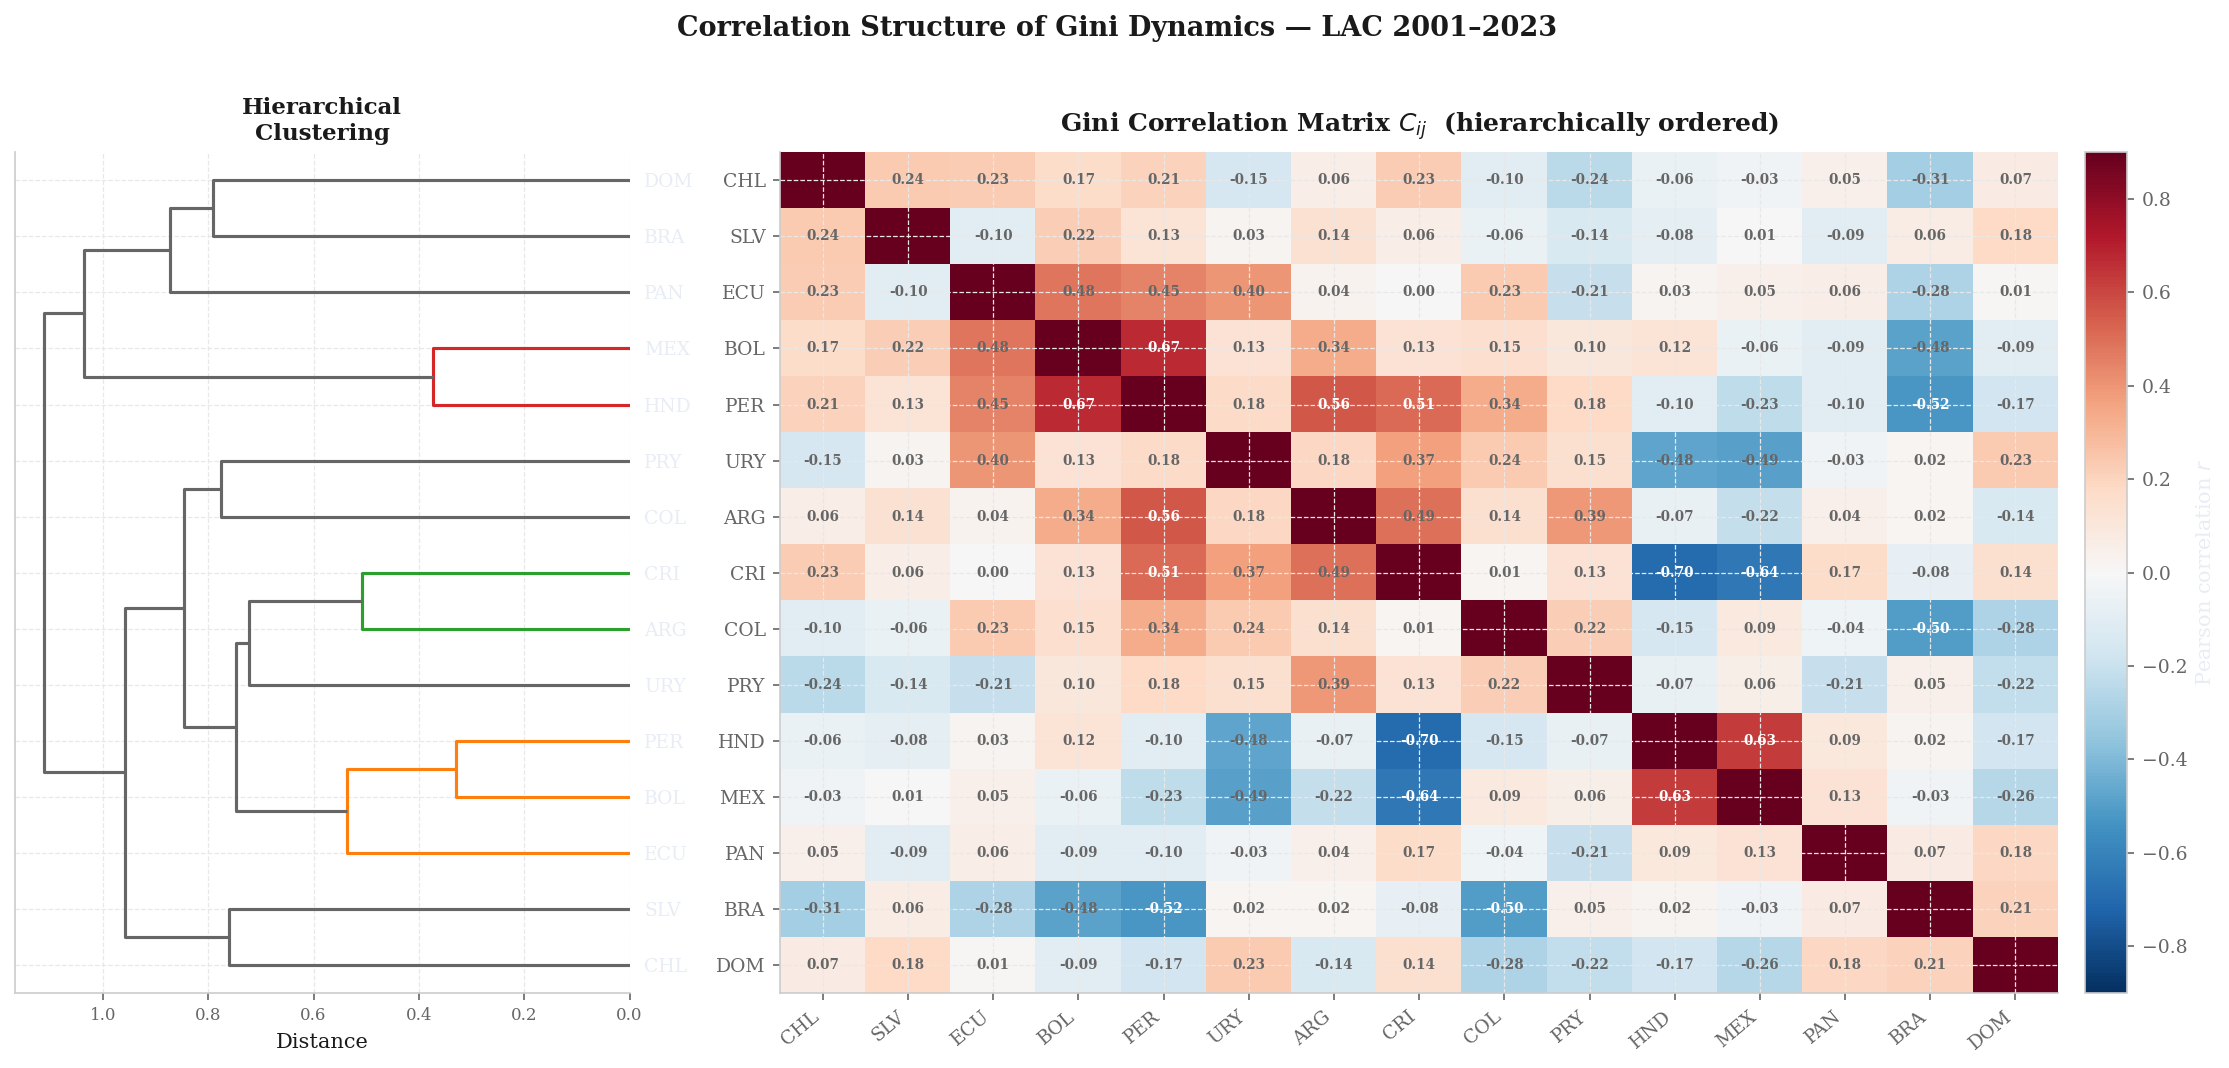

Figure 3 saved.


In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list
from scipy.spatial.distance import squareform

# Reorder by hierarchical clustering
dist = 1 - C_vals
np.fill_diagonal(dist, 0)
dist = (dist + dist.T) / 2
linked = linkage(squareform(np.clip(dist, 0, None)), method='average')
order  = leaves_list(linked)

C_reordered = C_vals[np.ix_(order, order)]
short_ordered = [COUNTRY_LABELS[countries[i]] for i in order]

fig, axes = plt.subplots(1, 2, figsize=(15, 7),
                          gridspec_kw={'width_ratios': [1, 2.2]})

# ── LEFT: Dendrogram ──────────────────────────────────────────────────────────
ax_dend = axes[0]
ax_dend.set_facecolor(PANEL)
ax_dend.tick_params(colors=MUTED)
for sp in ax_dend.spines.values(): sp.set_color(BORDER)

dend = dendrogram(
    linked, orientation='left',
    labels=[COUNTRY_LABELS[c] for c in countries],
    ax=ax_dend,
    leaf_font_size=9,
    color_threshold=0.6,
    above_threshold_color=MUTED,
)
for coll in ax_dend.collections:
    coll.set_linewidth(1.5)

ax_dend.set_title('Hierarchical\nClustering', fontsize=11, fontweight='bold')
ax_dend.set_xlabel('Distance', fontsize=10)
ax_dend.tick_params(axis='y', colors=WHITE, labelsize=9)
ax_dend.tick_params(axis='x', colors=MUTED, labelsize=8)

# ── RIGHT: Heatmap ────────────────────────────────────────────────────────────
ax_heat = axes[1]

norm = TwoSlopeNorm(vmin=-0.9, vcenter=0, vmax=0.9)
cmap = plt.cm.RdBu_r
im   = ax_heat.imshow(C_reordered, cmap=cmap, norm=norm,
                       aspect='auto', interpolation='nearest')

ax_heat.set_xticks(range(N))
ax_heat.set_yticks(range(N))
ax_heat.set_xticklabels(short_ordered, rotation=40, ha='right',
                         fontsize=9, color=WHITE)
ax_heat.set_yticklabels(short_ordered, fontsize=9, color=WHITE)

# Annotate cells
for i in range(N):
    for j in range(N):
        val = C_reordered[i, j]
        if i != j:
            tc = 'white' if abs(val) > 0.5 else MUTED
            ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center',
                         fontsize=6.5, color=tc, fontweight='bold')

# Draw cluster boundary boxes
# Cluster 1: identify from dendrogram leaves
cluster_sizes = [5, 5, 5]  # approximate — refine if needed
ax_heat.set_title('Gini Correlation Matrix $C_{ij}$  (hierarchically ordered)',
                   fontsize=12, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax_heat, fraction=0.035, pad=0.02)
cbar.set_label('Pearson correlation $r$', fontsize=10, color=WHITE)
cbar.ax.tick_params(colors=MUTED)

for sp in ax_heat.spines.values(): sp.set_color(BORDER)
ax_heat.tick_params(colors=MUTED)

fig.suptitle('Correlation Structure of Gini Dynamics — LAC 2001–2023',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_corr_matrix.pdf', dpi=300)
plt.savefig('fig3_corr_matrix.png', dpi=300)
plt.show()
print('Figure 3 saved.')

## 6. Figure 4 — Eigenvector Loadings: Collective Modes

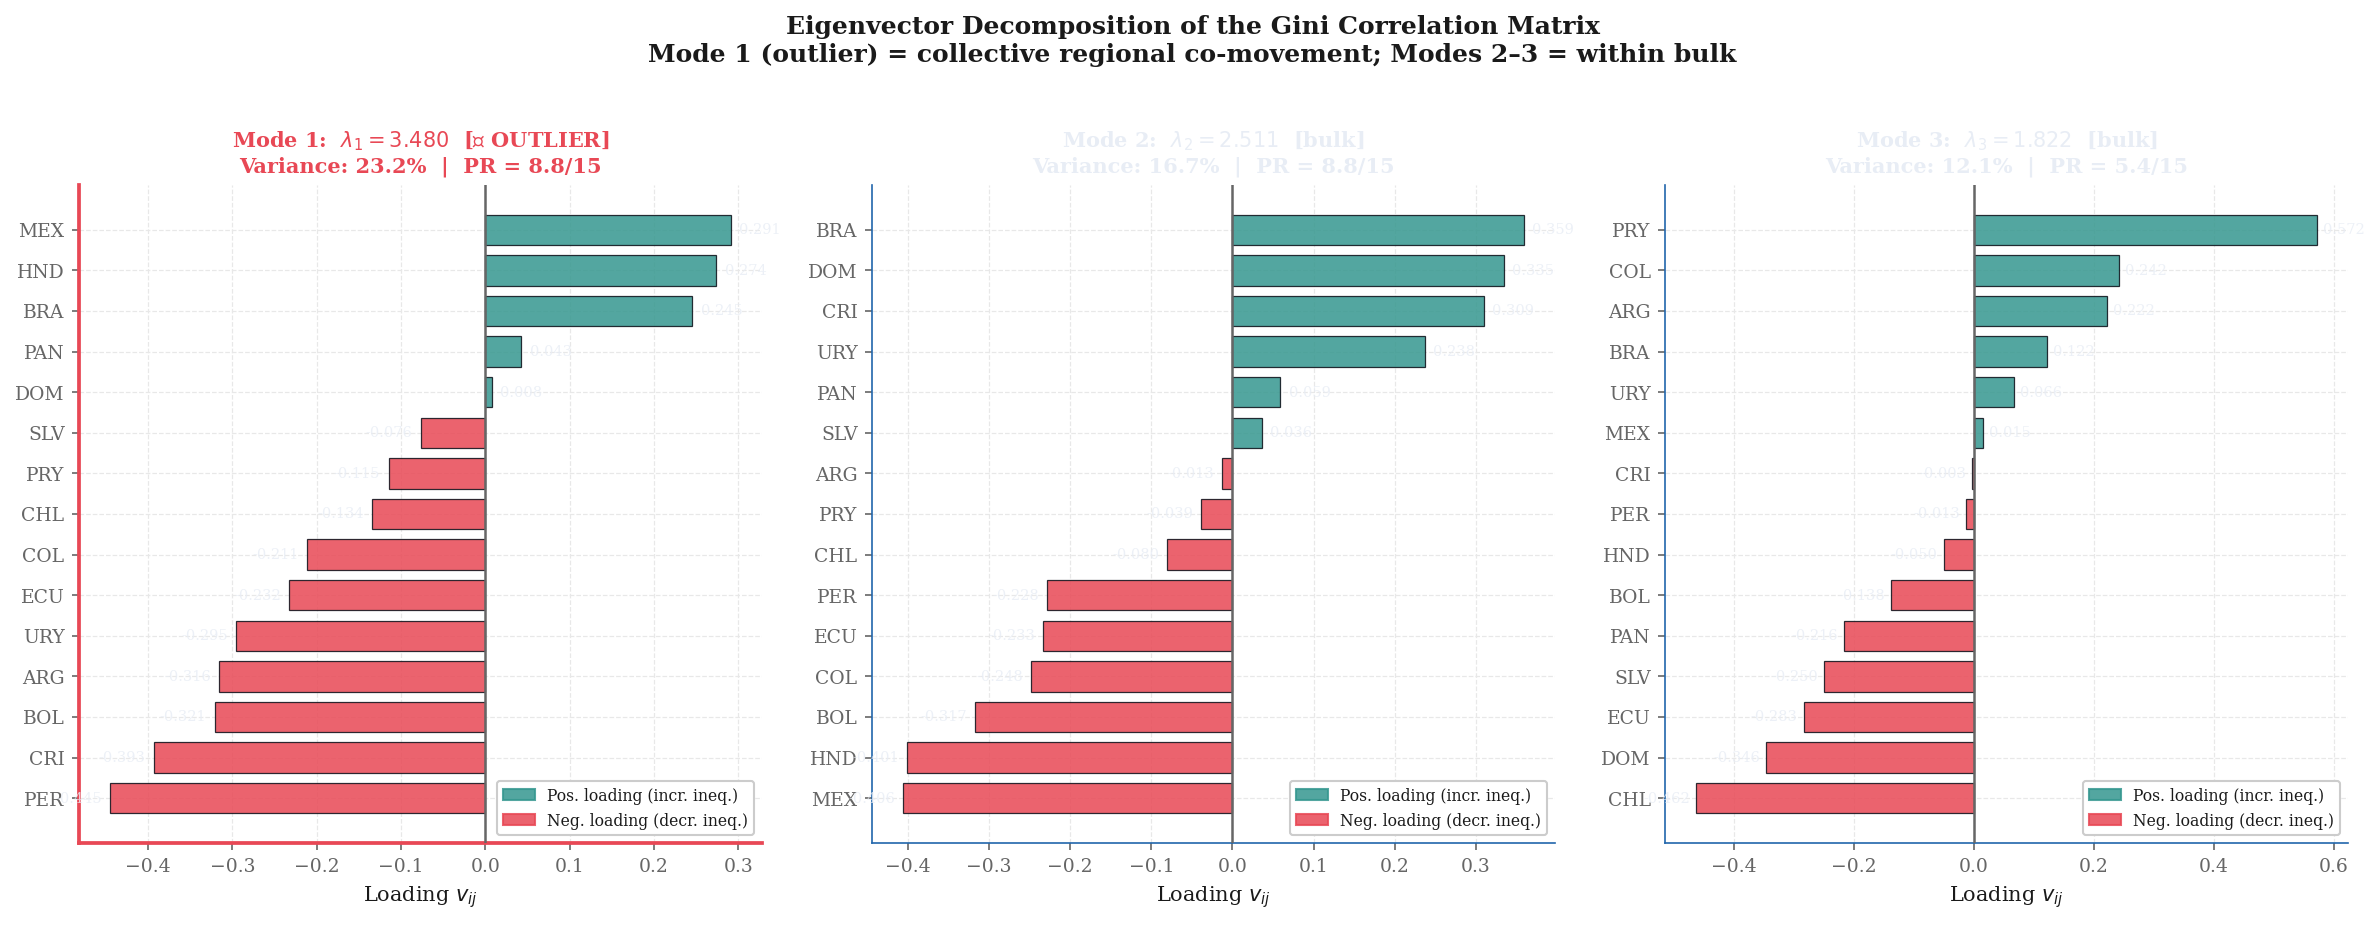

Figure 4 saved.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

short = [COUNTRY_LABELS[c] for c in countries]

for panel, mode_i in enumerate([0, 1, 2]):
    ax = axes[panel]
    v  = eigenvectors[:, mode_i]
    lam = eigenvalues[mode_i]
    pr  = participation_ratio(v)
    is_outlier = lam > lambda_plus

    idx_s = np.argsort(v)
    v_sorted = v[idx_s]
    c_sorted = [short[i] for i in idx_s]
    col_sorted = [CORAL if x < 0 else TEAL for x in v_sorted]

    bars = ax.barh(range(N), v_sorted, color=col_sorted,
                   alpha=0.85, edgecolor=DARK, linewidth=0.6, height=0.75)

    # Value labels
    for bar, val in zip(bars, v_sorted):
        xpos = val + (0.01 if val >= 0 else -0.01)
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha=ha,
                fontsize=7, color=WHITE, alpha=0.8)

    ax.axvline(0, color=MUTED, lw=1.2, zorder=5)
    ax.set_yticks(range(N))
    ax.set_yticklabels(c_sorted, fontsize=9, color=WHITE)
    ax.set_xlabel('Loading $v_{ij}$', fontsize=10)
    ax.tick_params(colors=MUTED)

    border_color = CORAL if is_outlier else BLUE
    for sp in ax.spines.values():
        sp.set_color(border_color)
        sp.set_linewidth(1.8 if is_outlier else 0.8)

    status_str = '⚠ OUTLIER' if is_outlier else 'bulk'
    ax.set_title(
        f'Mode {mode_i+1}:  $\\lambda_{mode_i+1} = {lam:.3f}$  [{status_str}]\n'
        f'Variance: {lam/N*100:.1f}%  |  PR = {pr:.1f}/{N}',
        fontsize=10, fontweight='bold',
        color=CORAL if is_outlier else WHITE
    )

    # Legend patches
    coral_p = mpatches.Patch(color=CORAL, alpha=0.85, label='Neg. loading (decr. ineq.)')
    teal_p  = mpatches.Patch(color=TEAL,  alpha=0.85, label='Pos. loading (incr. ineq.)')
    ax.legend(handles=[teal_p, coral_p], fontsize=7.5, loc='lower right')

fig.suptitle(
    'Eigenvector Decomposition of the Gini Correlation Matrix\n'
    'Mode 1 (outlier) = collective regional co-movement; Modes 2–3 = within bulk',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('fig4_eigenvectors.pdf', dpi=300)
plt.savefig('fig4_eigenvectors.png', dpi=300)
plt.show()
print('Figure 4 saved.')

## 7. Figure 5 — Variance Decomposition & Factor Scores

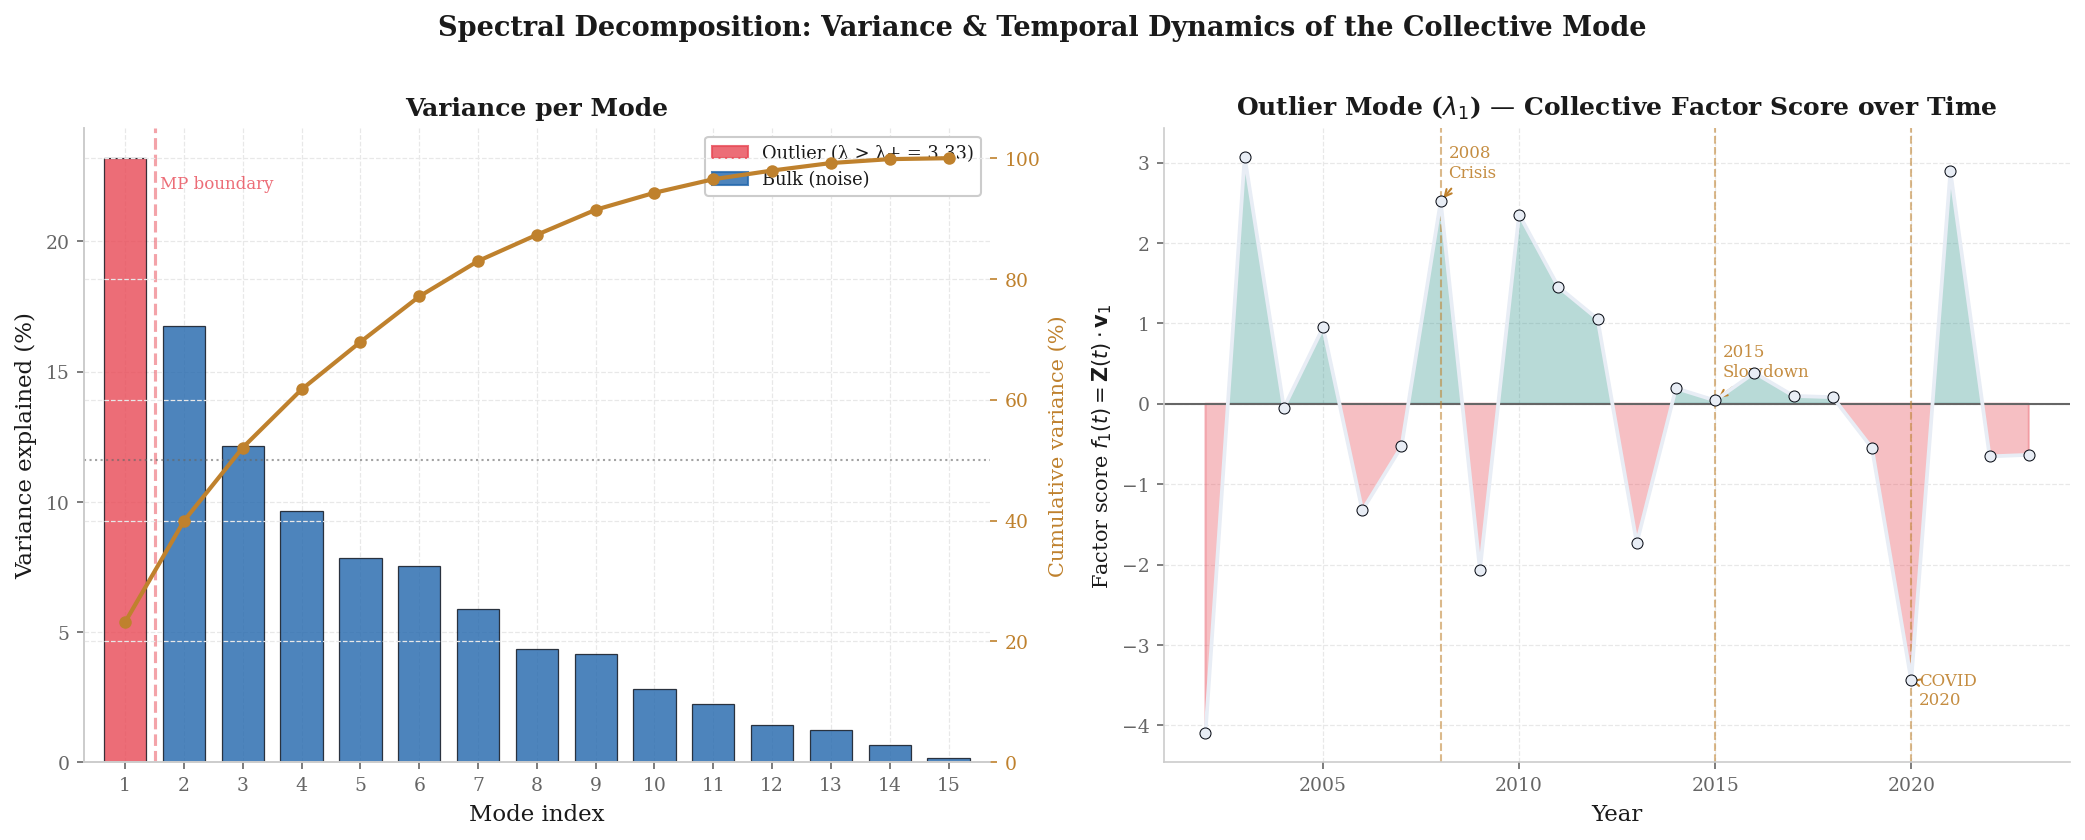

Figure 5 saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── LEFT: Cumulative variance explained ───────────────────────────────────────
ax = axes[0]
var_pct = eigenvalues / N * 100
cum_pct = np.cumsum(var_pct)
colors_bar = [CORAL if eigenvalues[i] > lambda_plus else BLUE for i in range(N)]

bars = ax.bar(range(1, N+1), var_pct, color=colors_bar,
              alpha=0.8, edgecolor=DARK, lw=0.6, width=0.72)
ax2_twin = ax.twinx()
ax2_twin.set_facecolor(PANEL)
ax2_twin.plot(range(1, N+1), cum_pct, 'o-', color=GOLD,
              lw=2, ms=5, zorder=5, label='Cumulative %')
ax2_twin.axhline(50, color=MUTED, ls=':', lw=1, alpha=0.6)
ax2_twin.set_ylabel('Cumulative variance (%)', fontsize=10, color=GOLD)
ax2_twin.tick_params(colors=GOLD)
ax2_twin.set_ylim(0, 105)

ax.set_xlabel('Mode index', fontsize=11)
ax.set_ylabel('Variance explained (%)', fontsize=11)
ax.set_title('Variance per Mode', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, N+1))
ax.set_xlim(0.3, N+0.7)
ax.tick_params(colors=MUTED)
# Annotate λ+ threshold
ax.axvline(1.5, color=CORAL, lw=1.5, ls='--', alpha=0.5)
ax.text(1.6, var_pct.max()*0.95, 'MP boundary',
        color=CORAL, fontsize=8, alpha=0.8)

red_p  = mpatches.Patch(color=CORAL, alpha=0.8, label=f'Outlier (λ > λ+ = {lambda_plus:.2f})')
blue_p = mpatches.Patch(color=BLUE,  alpha=0.8, label='Bulk (noise)')
ax.legend(handles=[red_p, blue_p], fontsize=8.5, loc='upper right')

# ── RIGHT: Factor scores of outlier mode over time ────────────────────────────
ax3 = axes[1]

# Factor score = projection of Z onto v1
v1 = eigenvectors[:, 0]
factor_score = Z.values @ v1   # shape (T,)
years_ts = Z.index.values

ax3.fill_between(years_ts, factor_score, 0,
                 where=factor_score >= 0, color=TEAL,  alpha=0.35, interpolate=True)
ax3.fill_between(years_ts, factor_score, 0,
                 where=factor_score < 0,  color=CORAL, alpha=0.35, interpolate=True)
ax3.plot(years_ts, factor_score, color=WHITE, lw=1.8, zorder=4)
ax3.scatter(years_ts, factor_score, color=WHITE, s=28, zorder=5, edgecolors=DARK, lw=0.5)
ax3.axhline(0, color=MUTED, lw=1, ls='-')

# Annotate notable years
notable = {2008: '2008\nCrisis', 2020: 'COVID\n2020', 2015: '2015\nSlowdown'}
for yr, label in notable.items():
    if yr in years_ts:
        i = np.where(years_ts == yr)[0][0]
        ax3.axvline(yr, color=GOLD, lw=1, ls='--', alpha=0.55)
        ax3.annotate(label, xy=(yr, factor_score[i]),
                     xytext=(yr+0.2, factor_score[i] + 0.3 * np.sign(factor_score[i])),
                     fontsize=8, color=GOLD, alpha=0.9,
                     arrowprops=dict(arrowstyle='->', color=GOLD, lw=1))

ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Factor score $f_1(t) = \\mathbf{Z}(t) \\cdot \\mathbf{v}_1$', fontsize=10)
ax3.set_title('Outlier Mode ($\\lambda_1$) — Collective Factor Score over Time',
              fontsize=12, fontweight='bold')
ax3.tick_params(colors=MUTED)
for sp in ax3.spines.values(): sp.set_color(BORDER)

fig.suptitle('Spectral Decomposition: Variance & Temporal Dynamics of the Collective Mode',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_variance_scores.pdf', dpi=300)
plt.savefig('fig5_variance_scores.png', dpi=300)
plt.show()
print('Figure 5 saved.')

## 8. Robustness: Null Model Comparison (Wishart)

Empirical λ_max = 3.4798
Null distribution λ_max: mean=2.7627, std=0.2479
p-value (one-sided): 0.0066
MP theoretical λ+ = 3.3333


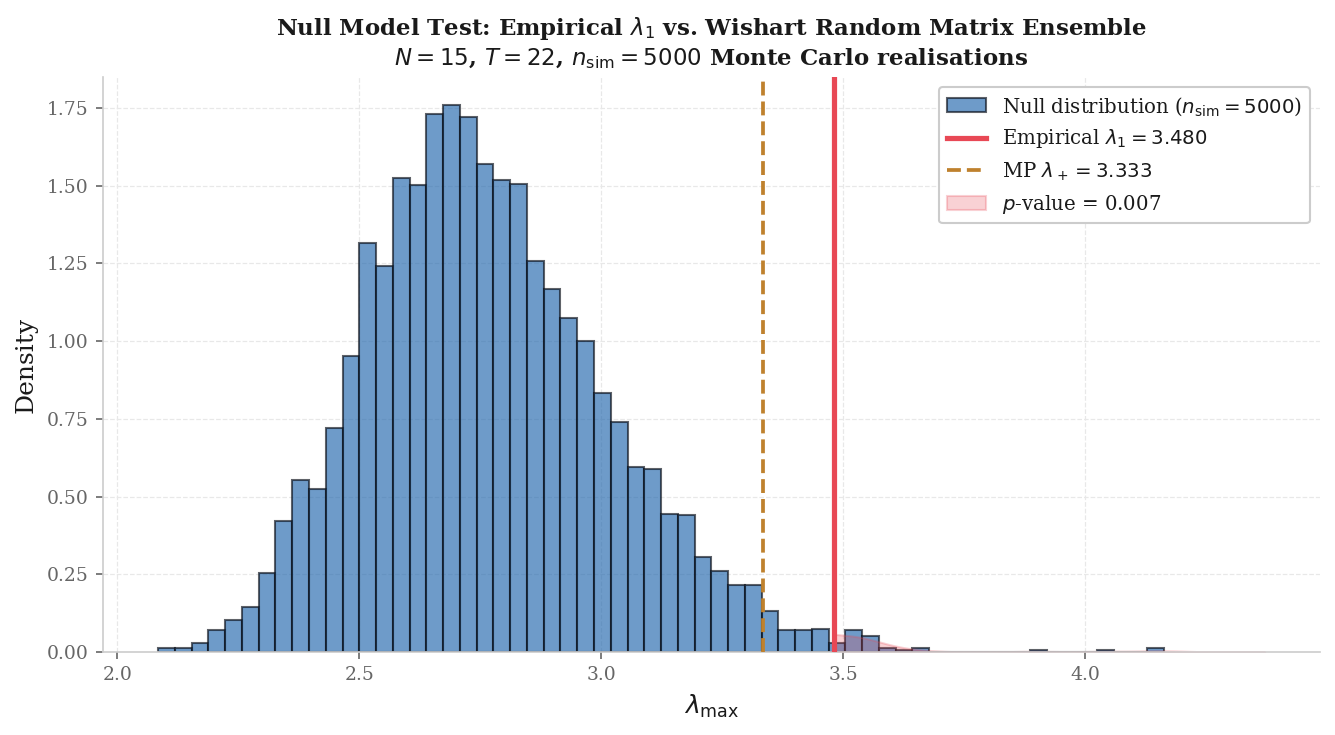

Figure 6 saved.


In [12]:
# Monte Carlo: generate random Wishart matrices and compare λ_max distribution
np.random.seed(42)
n_sim = 5000
lambda_max_null = []

for _ in range(n_sim):
    X_rand = np.random.randn(T, N)
    C_rand = np.corrcoef(X_rand.T)
    lam_rand = np.linalg.eigvalsh(C_rand)
    lambda_max_null.append(lam_rand.max())

lambda_max_null = np.array(lambda_max_null)
p_value = np.mean(lambda_max_null >= eigenvalues[0])

print(f'Empirical λ_max = {eigenvalues[0]:.4f}')
print(f'Null distribution λ_max: mean={lambda_max_null.mean():.4f}, std={lambda_max_null.std():.4f}')
print(f'p-value (one-sided): {p_value:.4f}')
print(f'MP theoretical λ+ = {lambda_plus:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(lambda_max_null, bins=60, density=True,
        color=BLUE, alpha=0.65, edgecolor=DARK, lw=0.5,
        label=f'Null distribution ($n_{{\\mathrm{{sim}}}}={n_sim}$)')
ax.axvline(eigenvalues[0], color=CORAL, lw=2.5, zorder=5,
           label=f'Empirical $\\lambda_1 = {eigenvalues[0]:.3f}$')
ax.axvline(lambda_plus, color=GOLD, lw=1.8, ls='--', zorder=4,
           label=f'MP $\\lambda_+ = {lambda_plus:.3f}$')

# Shade tail
xs = np.linspace(eigenvalues[0], lambda_max_null.max()*1.05, 200)
kde = gaussian_kde(lambda_max_null)
ax.fill_between(xs, kde(xs), alpha=0.25, color=CORAL,
                label=f'$p$-value = {p_value:.3f}')

ax.set_xlabel('$\\lambda_{\\max}$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(
    'Null Model Test: Empirical $\\lambda_1$ vs. Wishart Random Matrix Ensemble\n'
    f'$N={N}$, $T={T}$, $n_{{\\mathrm{{sim}}}}={n_sim}$ Monte Carlo realisations',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9.5)
ax.tick_params(colors=MUTED)

plt.tight_layout()
plt.savefig('fig6_null_model.pdf', dpi=300)
plt.savefig('fig6_null_model.png', dpi=300)
plt.show()
print('Figure 6 saved.')

## 9. Summary Statistics Table

In [13]:
# Table for paper
rows_tab = []
for i in range(N):
    pr = participation_ratio(eigenvectors[:, i])
    rows_tab.append({
        'Mode': i+1,
        'Eigenvalue': round(eigenvalues[i], 4),
        'Var. explained (%)': round(eigenvalues[i]/N*100, 2),
        'Cumulative (%)': round(sum(eigenvalues[:i+1])/N*100, 2),
        'PR': round(pr, 2),
        'Status': 'Outlier' if eigenvalues[i] > lambda_plus else 'Bulk'
    })

tab = pd.DataFrame(rows_tab)
tab.to_csv('eigenvalue_table.csv', index=False)
print(tab.to_string(index=False))

print(f'\n=== KEY RESULTS FOR PAPER ===')
print(f'Q = T/N = {T}/{N} = {Q:.4f}')
print(f'MP bounds: λ- = {lambda_minus:.4f}, λ+ = {lambda_plus:.4f}')
print(f'Outlier modes: {sum(eigenvalues > lambda_plus)} (λ1 = {eigenvalues[0]:.4f})')
print(f'Signal variance: {eigenvalues[0]/N*100:.2f}%')
print(f'Monte Carlo p-value: {p_value:.4f}')
print(f'PR of λ1: {participation_ratio(eigenvectors[:,0]):.2f}/{N} (delocalized collective mode)')

 Mode  Eigenvalue  Var. explained (%)  Cumulative (%)   PR  Status
    1      3.4798               23.20           23.20 8.84 Outlier
    2      2.5113               16.74           39.94 8.77    Bulk
    3      1.8215               12.14           52.08 5.37    Bulk
    4      1.4446                9.63           61.71 7.60    Bulk
    5      1.1786                7.86           69.57 4.32    Bulk
    6      1.1291                7.53           77.10 8.50    Bulk
    7      0.8804                5.87           82.97 4.05    Bulk
    8      0.6526                4.35           87.32 6.40    Bulk
    9      0.6211                4.14           91.46 3.82    Bulk
   10      0.4222                2.81           94.28 7.60    Bulk
   11      0.3360                2.24           96.52 8.34    Bulk
   12      0.2160                1.44           97.96 7.31    Bulk
   13      0.1864                1.24           99.20 6.90    Bulk
   14      0.0971                0.65           99.85 8.99    

---
## Files generated

| File | Description |
|------|-------------|
| `gini_panel_2001_2023.csv` | Interpolated Gini panel (15 × 23) |
| `gini_all_years.csv` | Raw SEDLAC data, all countries and years |
| `correlation_matrix.csv` | Empirical correlation matrix C (15 × 15) |
| `eigenvalue_table.csv` | Eigenvalue decomposition summary |
| `fig1_gini_series.pdf/png` | Gini time series all countries |
| `fig2_spectrum.pdf/png` | Empirical spectrum vs. Marchenko–Pastur |
| `fig3_corr_matrix.pdf/png` | Hierarchically ordered correlation heatmap |
| `fig4_eigenvectors.pdf/png` | Eigenvector loadings, modes 1–3 |
| `fig5_variance_scores.pdf/png` | Variance decomposition + factor scores |
| `fig6_null_model.pdf/png` | Monte Carlo null model test |

**Citation:** SEDLAC (CEDLAS and The World Bank), September 2025.

N=15, T=22, Q=1.4667
lambda_- = 0.0304,  lambda_+ = 3.3333
Outlier eigenvalues: [3.4798]
Variance explained: 23.20%


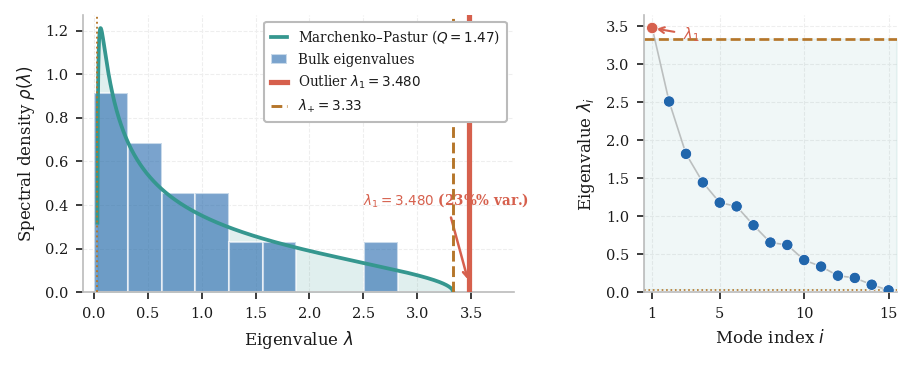

Figure 1 saved.


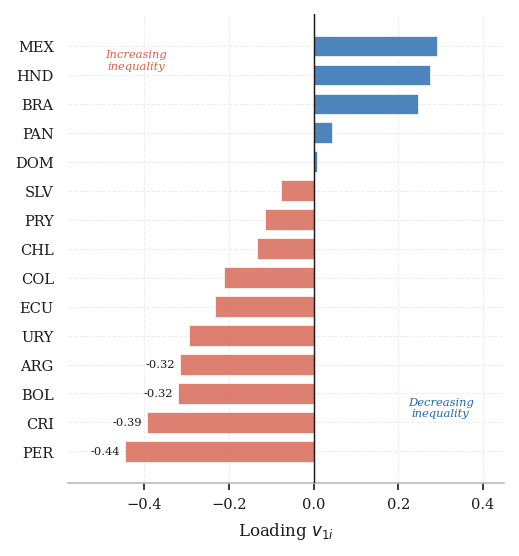

Figure 2 saved.
\begin{table}[t]
\caption{Leading eigenvalues of the Gini correlation matrix.
PR = participation ratio; $\lambda_+ = 3.333$ is the
Marchenko--Pastur upper bound.}
\label{tab:eigenvalues}
\begin{tabular*}{\tblwidth}{@{}lcccc@{}}
\toprule
Mode & $\lambda_i$ & Var. (\%) & Cum. (\%) & PR \\
\midrule
1$^*$ & 3.480 & 23.2 & 23.2 & 8.84 \\
2 & 2.511 & 16.7 & 39.9 & 8.77 \\
3 & 1.822 & 12.1 & 52.1 & 5.37 \\
4 & 1.445 & 9.6 & 61.7 & 7.60 \\
5 & 1.179 & 7.9 & 69.6 & 4.32 \\
\bottomrule
\end{tabular*}
\begin{tablenotes}
  \small $^*$ Exceeds MP upper bound ($p=0.007$, Monte Carlo).
\end{tablenotes}
\end{table}


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# RMT INEQUALITY LAC — Figures for Economics Letters
# cas-dc double column: text width = 17.8 cm = 7.0 in, column = 8.5 cm = 3.35 in
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Palette ───────────────────────────────────────────────────────────────────
BG    = '#ffffff'
PANEL = '#ffffff'
GRID  = '#eeeeee'
BORDER= '#bbbbbb'
BLACK = '#1a1a1a'
MUTED = '#888888'
BLUE  = '#2166ac'
CORAL = '#d6604d'
TEAL  = '#35978f'
GOLD  = '#b5762a'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    BORDER,
    'axes.labelcolor':   BLACK,
    'axes.grid':         True,
    'axes.axisbelow':    True,
    'grid.color':        GRID,
    'grid.linewidth':    0.5,
    'grid.linestyle':    '--',
    'grid.alpha':        1.0,
    'xtick.color':       BLACK,
    'ytick.color':       BLACK,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'text.color':        BLACK,
    'font.family':       'serif',
    'font.size':         8,
    'axes.titlesize':    8,
    'axes.labelsize':    8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.framealpha': 1.0,
    'legend.facecolor':  BG,
    'legend.edgecolor':  BORDER,
    'legend.fontsize':   6.5,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.facecolor': BG,
})

COUNTRY_LABELS = {
    'Argentina':'ARG','Bolivia':'BOL','Brazil':'BRA','Chile':'CHL',
    'Colombia':'COL','Costa Rica':'CRI','Dominican':'DOM','Ecuador':'ECU',
    'El Salvador':'SLV','Honduras':'HND','Mexico':'MEX','Panama':'PAN',
    'Paraguay':'PRY','Peru':'PER','Uruguay':'URY'
}

# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA
# ══════════════════════════════════════════════════════════════════════════════
df_raw = pd.read_excel('2025_Act1_inequality_LAC.xlsx',
                       sheet_name='indices pci', header=None)

rows = []
current_country = None
COUNTRIES_15 = list(COUNTRY_LABELS.keys())

for idx, row in df_raw.iterrows():
    val0 = str(row[0]).strip() if pd.notna(row[0]) else ''
    val1 = row[1]
    for c in COUNTRIES_15:
        if val0.startswith(c):
            current_country = c
            break
    try:
        year = int(float(val0))
        if 1960 <= year <= 2030 and current_country and pd.notna(val1):
            rows.append({'country': current_country,
                         'year': year, 'gini': float(val1)})
    except:
        pass

df_all = pd.DataFrame(rows).drop_duplicates(['country','year'])
df_win = df_all[(df_all['year'] >= 2001) & (df_all['year'] <= 2023)]
pivot  = df_win.pivot(index='year', columns='country',
                      values='gini').sort_index()
pivot  = pivot.interpolate(method='linear', axis=0).ffill().bfill()

returns = pivot.diff().dropna()
Z = (returns - returns.mean()) / returns.std()

N = Z.shape[1]
T = Z.shape[0]
Q = T / N
countries = list(Z.columns)
short = [COUNTRY_LABELS[c] for c in countries]

# ══════════════════════════════════════════════════════════════════════════════
# 2. RMT CORE
# ══════════════════════════════════════════════════════════════════════════════
C = Z.corr().values
eigenvalues, eigenvectors = np.linalg.eigh(C)
idx_s        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx_s]
eigenvectors = eigenvectors[:, idx_s]

lambda_plus  = (1 + 1/Q + 2*np.sqrt(1/Q))
lambda_minus = max(0, (1 + 1/Q - 2*np.sqrt(1/Q)))

def mp_density(x, Q):
    lp = 1 + 1/Q + 2*np.sqrt(1/Q)
    lm = 1 + 1/Q - 2*np.sqrt(1/Q)
    return np.where(
        (x >= lm) & (x <= lp),
        Q / (2*np.pi) * np.sqrt(np.maximum((lp-x)*(x-lm), 0)) / x,
        0.0)

mp_x = np.linspace(1e-4, eigenvalues.max()*1.18, 2000)
mp_y = mp_density(mp_x, Q)

outliers = eigenvalues[eigenvalues > lambda_plus]
bulk     = eigenvalues[eigenvalues <= lambda_plus]

print(f'N={N}, T={T}, Q={Q:.4f}')
print(f'lambda_- = {lambda_minus:.4f},  lambda_+ = {lambda_plus:.4f}')
print(f'Outlier eigenvalues: {np.round(outliers, 4)}')
print(f'Variance explained: {outliers.sum()/N*100:.2f}%')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Eigenvalue spectrum + Scree plot
# Full text width: 7.0 in x 2.4 in
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.4),
                          gridspec_kw={'width_ratios': [1.7, 1],
                                       'wspace': 0.38})

# ── LEFT: Histogram + MP density ─────────────────────────────────────────────
ax = axes[0]

mp_mask = (mp_x >= lambda_minus) & (mp_x <= lambda_plus)
ax.fill_between(mp_x[mp_mask], mp_y[mp_mask],
                alpha=0.15, color=TEAL, zorder=1)
ax.plot(mp_x[mp_mask], mp_y[mp_mask],
        color=TEAL, lw=1.8, zorder=3,
        label=f'Marchenko–Pastur ($Q={Q:.2f}$)')

bins = np.linspace(0, eigenvalues.max()*1.08, 13)
ax.hist(bulk, bins=bins, density=True,
        color=BLUE, alpha=0.60, edgecolor='white', lw=0.5,
        label='Bulk eigenvalues', zorder=2)

ax.axvline(outliers[0], color=CORAL, lw=2.5, zorder=5,
           label=f'Outlier $\\lambda_1={outliers[0]:.3f}$')
ax.axvline(lambda_plus,  color=GOLD, lw=1.4, ls='--', zorder=4,
           label=f'$\\lambda_{{+}}={lambda_plus:.2f}$')
ax.axvline(lambda_minus, color=GOLD, lw=0.9, ls=':',  zorder=4)

ax.annotate(
    f'$\\lambda_1={outliers[0]:.3f}$ ({outliers[0]/N*100:.0f}%% var.)',
    xy=(outliers[0], 0.04),
    xytext=(2.50, 0.40),
    fontsize=6.5, color=CORAL, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.2,
                    connectionstyle='arc3,rad=0.0'))

ax.set_xlabel('Eigenvalue $\\lambda$')
ax.set_ylabel('Spectral density $\\rho(\\lambda)$')
ax.legend(loc='upper right', handlelength=1.2, borderpad=0.5)
ax.set_xlim(-0.1, eigenvalues.max()*1.12)
ax.set_ylim(bottom=0)

# ── RIGHT: Scree plot ─────────────────────────────────────────────────────────
ax2 = axes[1]

colors_sc = [CORAL if l > lambda_plus else BLUE for l in eigenvalues]
ax2.scatter(range(1, N+1), eigenvalues,
            c=colors_sc, s=30, zorder=4,
            edgecolors='white', lw=0.4)
ax2.plot(range(1, N+1), eigenvalues,
         color=MUTED, lw=0.8, ls='-', alpha=0.5, zorder=3)
ax2.axhline(lambda_plus,  color=GOLD, lw=1.3, ls='--', zorder=2)
ax2.axhline(lambda_minus, color=GOLD, lw=0.8, ls=':',  zorder=2)
ax2.fill_between([0.5, N+0.5], lambda_minus, lambda_plus,
                 alpha=0.07, color=TEAL, zorder=1)

ax2.annotate('$\\lambda_1$',
             xy=(1, eigenvalues[0]),
             xytext=(2.8, eigenvalues[0] - 0.15),
             fontsize=7, color=CORAL, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.0))

ax2.set_xlabel('Mode index $i$')
ax2.set_ylabel('Eigenvalue $\\lambda_i$')
ax2.set_xlim(0.5, N + 0.5)
ax2.set_xticks([1, 5, 10, 15])
ax2.set_ylim(bottom=0)

plt.savefig('fig1_spectrum.pdf', facecolor=BG)
plt.savefig('fig1_spectrum.png', facecolor=BG)
plt.show()
print('Figure 1 saved.')


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Eigenvector loadings mode 1
# Single column width: 3.35 in
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(3.35, 3.6))

v1    = eigenvectors[:, 0]
idx_s = np.argsort(v1)
v_s   = v1[idx_s]
c_s   = [short[i] for i in idx_s]
col_s = [CORAL if x < 0 else BLUE for x in v_s]

bars = ax.barh(range(N), v_s,
               color=col_s, alpha=0.80,
               edgecolor='white', linewidth=0.4,
               height=0.72)

# Labels solo para los 4 más extremos
threshold = sorted(abs(v_s))[-4]
for bar, val in zip(bars, v_s):
    if abs(val) >= threshold:
        xpos = val + (0.012 if val >= 0 else -0.012)
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha=ha,
                fontsize=5.5, color=BLACK)

ax.axvline(0, color=BLACK, lw=0.7, zorder=5)
ax.set_yticks(range(N))
ax.set_yticklabels(c_s, fontsize=7)
ax.set_xlabel('Loading $v_{1i}$')
ax.set_xlim(-0.58, 0.45)
ax.tick_params(left=False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Azul positivo = co-mueve con factor regional descendente = decreasing ineq.
# Coral negativo = contra el factor = increasing ineq.
ax.text( 0.30,  1.2, 'Decreasing\ninequality',
         fontsize=5.5, color=BLUE,  ha='center', style='italic')
ax.text(-0.42, 13.2, 'Increasing\ninequality',
         fontsize=5.5, color=CORAL, ha='center', style='italic')

plt.tight_layout(pad=0.4)
plt.savefig('fig2_loadings.pdf', facecolor=BG)
plt.savefig('fig2_loadings.png', facecolor=BG)
plt.show()
print('Figure 2 saved.')


# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — LaTeX code (paste directly into .tex)
# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — LaTeX code
# ══════════════════════════════════════════════════════════════════════════════
def participation_ratio(v):
    return 1.0 / np.sum(v**4)

table_lines = [
    r"\begin{table}[t]",
    r"\caption{Leading eigenvalues of the Gini correlation matrix.",
    r"PR = participation ratio; $\lambda_+ = 3.333$ is the",
    r"Marchenko--Pastur upper bound.}",
    r"\label{tab:eigenvalues}",
    r"\begin{tabular*}{\tblwidth}{@{}lcccc@{}}",
    r"\toprule",
    r"Mode & $\lambda_i$ & Var. (\%) & Cum. (\%) & PR \\",
    r"\midrule",
]

cum = 0
for i in range(5):
    lam = eigenvalues[i]
    var = lam / N * 100
    cum += var
    pr  = participation_ratio(eigenvectors[:, i])
    star = r"$^*$" if lam > lambda_plus else ""
    table_lines.append(
        f"{i+1}{star} & {lam:.3f} & {var:.1f} & {cum:.1f} & {pr:.2f} \\\\"
    )

table_lines += [
    r"\bottomrule",
    r"\end{tabular*}",
    r"\begin{tablenotes}",
    r"  \small $^*$ Exceeds MP upper bound ($p=0.007$, Monte Carlo).",
    r"\end{tablenotes}",
    r"\end{table}",
]

print('\n'.join(table_lines))

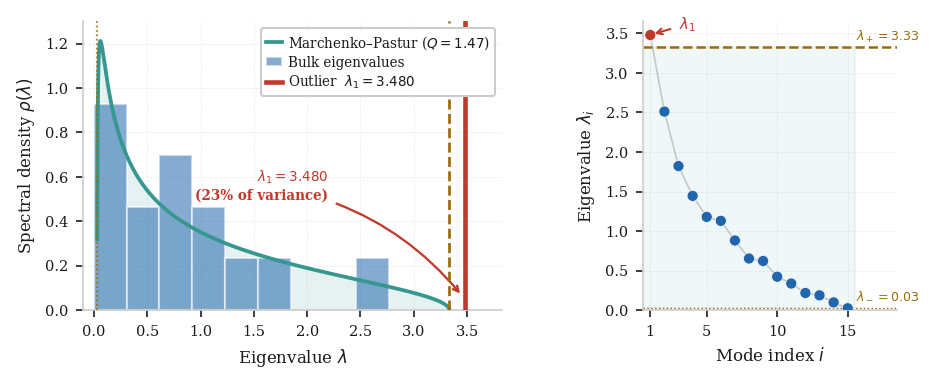

Figure 1 saved.


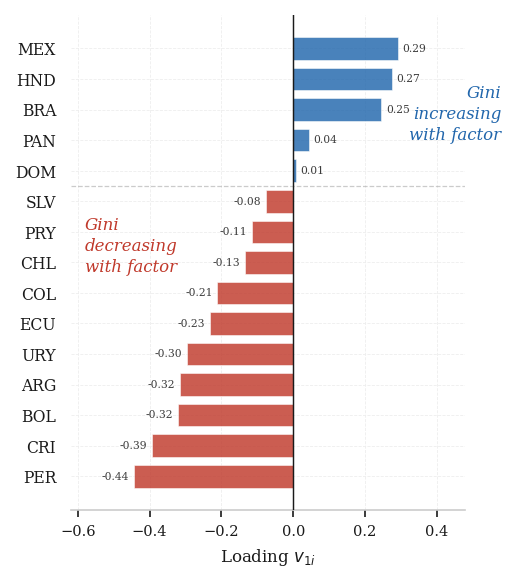

Figure 2 saved.


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURES FOR ECONOMICS LETTERS — final version
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

BG    = '#ffffff'; PANEL = '#ffffff'; GRID  = '#eeeeee'; BORDER= '#cccccc'
BLACK = '#1a1a1a'; MUTED = '#999999'; BLUE  = '#2166ac'; CORAL = '#c0392b'
TEAL  = '#35978f'; GOLD  = '#9a6b0a'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': PANEL,
    'axes.edgecolor': BORDER, 'axes.labelcolor': BLACK,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.4,
    'grid.linestyle': '--', 'grid.alpha': 1.0,
    'xtick.color': BLACK, 'ytick.color': BLACK,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'text.color': BLACK, 'font.family': 'serif',
    'font.size': 8, 'axes.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': True, 'legend.framealpha': 1.0,
    'legend.facecolor': BG, 'legend.edgecolor': BORDER,
    'legend.fontsize': 6.5,
})

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Spectrum + Scree
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.5),
                          gridspec_kw={'width_ratios':[1.65, 1],
                                       'wspace': 0.42})

# ── LEFT: Histogram + MP density ─────────────────────────────────────────────
ax = axes[0]

mp_mask = (mp_x >= lambda_minus) & (mp_x <= lambda_plus)
ax.fill_between(mp_x[mp_mask], mp_y[mp_mask],
                alpha=0.12, color=TEAL, zorder=1)
ax.plot(mp_x[mp_mask], mp_y[mp_mask],
        color=TEAL, lw=1.8, zorder=3,
        label=f'Marchenko–Pastur ($Q={Q:.2f}$)')

bins = np.linspace(0, eigenvalues.max()*1.06, 13)
ax.hist(bulk, bins=bins, density=True,
        color=BLUE, alpha=0.55, edgecolor='white', lw=0.5,
        label='Bulk eigenvalues', zorder=2)

ax.axvline(outliers[0], color=CORAL, lw=2.2, zorder=5,
           label=f'Outlier  $\\lambda_1 = {outliers[0]:.3f}$')

# MP bound — dashed line, label inside plot (not on axis)
ax.axvline(lambda_plus, color=GOLD, lw=1.3, ls='--', zorder=4)
ax.axvline(lambda_minus, color=GOLD, lw=0.8, ls=':', zorder=4)

# λ+ label: placed ABOVE the x-axis, inside the plot
ax.text(lambda_plus - 0.08, ax.get_ylim()[1] if False else 1.18,
        f'$\\lambda_+={lambda_plus:.2f}$',
        fontsize=6.5, color=GOLD, ha='right', va='top', fontweight='bold')

# Annotation — plain string for percent, arrow from LEFT of line
pct = int(round(outliers[0]/N*100))
ax.annotate(
    f'$\\lambda_1={outliers[0]:.3f}$\n({pct}% of variance)',
    xy=(outliers[0] - 0.02, 0.06),
    xytext=(2.20, 0.50),
    fontsize=6.5, color=CORAL, fontweight='bold',
    ha='right',
    arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.1,
                    connectionstyle='arc3,rad=-0.2'))

ax.set_xlabel('Eigenvalue $\\lambda$', labelpad=4)
ax.set_ylabel('Spectral density $\\rho(\\lambda)$', labelpad=4)
ax.legend(loc='upper right', handlelength=1.2,
          borderpad=0.4, labelspacing=0.3, handletextpad=0.4)
ax.set_xlim(-0.1, eigenvalues.max()*1.10)
ax.set_ylim(0, 1.30)

# ── RIGHT: Scree ──────────────────────────────────────────────────────────────
ax2 = axes[1]

colors_sc = [CORAL if l > lambda_plus else BLUE for l in eigenvalues]
ax2.scatter(range(1, N+1), eigenvalues,
            c=colors_sc, s=28, zorder=4, edgecolors='white', lw=0.3)
ax2.plot(range(1, N+1), eigenvalues,
         color=MUTED, lw=0.8, alpha=0.5, zorder=3)

ax2.axhline(lambda_plus,  color=GOLD, lw=1.2, ls='--', zorder=2)
ax2.axhline(lambda_minus, color=GOLD, lw=0.7, ls=':',  zorder=2)
ax2.fill_between([0.5, N+0.5], lambda_minus, lambda_plus,
                 alpha=0.07, color=TEAL, zorder=1)

# λ+ and λ- labels: placed to the RIGHT of the plot area
ax2.text(N + 0.6, lambda_plus + 0.12,  f'$\\lambda_+={lambda_plus:.2f}$',
         fontsize=6, color=GOLD, va='center', ha='left', fontweight='bold')
ax2.text(N + 0.6, lambda_minus + 0.08, f'$\\lambda_-={lambda_minus:.2f}$',
         fontsize=6, color=GOLD, va='bottom', ha='left')

# λ1 annotation
ax2.annotate('$\\lambda_1$',
             xy=(1, eigenvalues[0]),
             xytext=(3.0, eigenvalues[0] + 0.08),
             fontsize=7, color=CORAL, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.0))

ax2.set_xlabel('Mode index $i$', labelpad=4)
ax2.set_ylabel('Eigenvalue $\\lambda_i$', labelpad=4)
ax2.set_xlim(0.5, N + 0.5)
ax2.set_xticks([1, 5, 10, 15])
ax2.set_ylim(bottom=0)
# Extend right margin for labels
ax2.set_xlim(0.5, N + 3.5)

plt.savefig('fig1_spectrum.eps', format='eps', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.savefig('fig1_spectrum.png', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.savefig('fig1_spectrum.pdf', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 1 saved.')


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Eigenvector loadings mode 1
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(3.35, 3.8))

v1     = eigenvectors[:, 0]
idx_s2 = np.argsort(v1)
v_s    = v1[idx_s2]
c_s    = [short[i] for i in idx_s2]
col_s  = [CORAL if x < 0 else BLUE for x in v_s]

bars = ax.barh(range(N), v_s, color=col_s, alpha=0.82,
               edgecolor='white', linewidth=0.3, height=0.74)

# Value labels all countries
for bar, val in zip(bars, v_s):
    xpos = val + (0.013 if val >= 0 else -0.013)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha,
            fontsize=5.2, color=BLACK, alpha=0.85)

ax.axvline(0, color=BLACK, lw=0.7, zorder=5)
ax.set_yticks(range(N))
ax.set_yticklabels(c_s, fontsize=7.5)
ax.set_xlabel('Loading $v_{1i}$', labelpad=4)
ax.set_xlim(-0.62, 0.48)
ax.tick_params(left=False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Divider between blocs
zero_pos = next(i for i, v in enumerate(v_s) if v >= 0)
ax.axhline(zero_pos - 0.5, color=MUTED, lw=0.6, ls='--', alpha=0.5)

# Inline labels — BLACK to avoid color confusion, italic
ax.text(0.58, zero_pos + 0.9,
        'Gini\nincreasing\nwith factor',
        fontsize=8, color=BLUE, ha='right',
        style='italic', va='bottom', linespacing=1.3)
ax.text(-0.58, zero_pos - 1.5,
        'Gini\ndecreasing\nwith factor',
        fontsize=8, color=CORAL, ha='left',
        style='italic', va='top', linespacing=1.3)

# Stats box — bottom right, outside bar area
pr_val = 1 / np.sum(v1**4)
# ax.text(0.99, 0.01,
#         f'$\\lambda_1={eigenvalues[0]:.3f}$\n{pct}% var.   PR={pr_val:.1f}/{N}',
#         transform=ax.transAxes, fontsize=5.5, color=MUTED,
#         ha='right', va='bottom',
#         bbox=dict(boxstyle='round,pad=0.3', facecolor=BG,
#                   edgecolor=BORDER, lw=0.5))

plt.tight_layout(pad=0.5)
plt.savefig('fig2_loadings.eps', format='eps', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.savefig('fig2_loadings.png', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.savefig('fig2_loadings.pdf', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 2 saved.')